Iniciamos importando las librerías que necesitaremos para llevar a cabo el caso

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
import re
from tqdm import tqdm

# Caso 4: Analizando Patrones en las Precipitaciones
En este caso se trabajará con la base de datos de las precipitaciones mensuales históricas para un conjunto de estaciones hidrológicas ubicadas a lo largo de diferentes cuencas del Departamento de Cundimarca, y también algunas ubicadas en el Departamento de Boyacá. Nuestro objetivo será encontrar anomalías en los niveles de precipitación para establecer la ocurrencia de periodos de exceso de lluvia o periodos de sequía.

## Resultado previsto de aprendizaje
Tras realizar este caso se espera que el estudiante pueda realizar descomposición de series de tiempo usando el paquete STL de la librería `statsmodels`. También se hará un especial énfasis en este caso a la creación de gráficas como *violinplot* o *boxplot* que el estudiante debe estar en capacidad de generar e interpretar.

---

## Contexto del Problema

A usted se le ha entregado una base de datos con la información de las precipitaciones mensuales obtenidas en todas las estaciones hidrológicas de la red de la Corporación Autónoma Regional de Cundinamarca - CAR. El objetivo es establecer un criterio para determinar cuándo existe una anomalía en los niveles de precipitaciones que pueda, posteriormente, ser interpretada como una ocurrencia del Fenómeno del Niño (niveles muy bajos de precipitación) o Fenómeno de la Niña (niveles muy altos de precipitación).

El problema, es que en Colombia existen naturalmente estaciones secas y lluviosas, cuya frecuencia y extensión dependen de la ubicación de la estación. De manera que el criterio escogido debe tener en cuenta esta estacionalidad.

### Cargando los datos

Arrancamos analizando la base de datos de precpitaciones que ha sido entregada por la Corporación Autónoma Regional de Cundimarca (CAR). El archivo es un archivo de Excel con múltiples hojas, cada hoja representa una estación hidrológica, y su contenido es el histórico mensual de precipitaciones en formato ancho (cada columna representa un mes, cada fila representa un año).

Para cargar los datos de la estación haremos 2 importaciones, la primera será general y nos permitirá obtener información sobre la estación: nombre, código, ubicación. La segunda importación estará dirigida a los datos.

#### Primera importación
Obteniendo información de la estación

In [2]:
info_data = pd.read_excel('data/HISTÓRICO DE PRECIPITACIONES MENSUALES.xlsx', sheet_name='2120074')
info_data

,C A R - CORPORACIÓN AUTÓNOMA REGIONAL DE CUNDINAMARCA,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,SICLICA - Sistema de Información Climatológica...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VALORES TOTALES MENSUALES DE PRECIPITACIÓN (mm),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ESTACIÓN : 2120074 ZIPAQUIRÁ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2020,NaN,NaN,"42,2",NaN,"60,5",NaN,"101,2",NaN,"42,1",...,NaN,"20,8",NaN,"83,8",NaN,"49,6",NaN,"242,2",NaN,"20,0"
93,2021,NaN,NaN,"5,2",NaN,"67,0",NaN,"139,7",NaN,"66,4",...,NaN,"86,5",NaN,"72,4",NaN,"205,1",NaN,"100,5",NaN,"55,6"
94,2022,NaN,NaN,"18,5",NaN,"69,2",NaN,"97,5",NaN,"121,5",...,NaN,"63,9",NaN,"151,2",NaN,"243,6",NaN,"170,8",NaN,"48,4"
95,2023,NaN,NaN,"93,7",NaN,"59,1",NaN,"132,2",NaN,"97,9",...,NaN,"41,4",NaN,"48,4",NaN,"124,8",NaN,"47,5",NaN,"48,2"


Busquemos ahora la información que necesitamos encontrar:

In [3]:
# Extrayendo la longitud
text = info_data.iloc[6,1] # ubicamos la celda que contiene la longitud
longitud = re.search(r'\d+', text).group() # buscamos el primer número en el texto
longitud = float(longitud) # convertimos a float
longitud = longitud / 100 # convertimos a grados decimales
print(longitud)

# Extrayendo la latitud en una sola línea
latitud = float(re.search(r'\d+', info_data.iloc[7,1]).group()) / 100 # el mismo proceso en una sola línea
print(latitud)

# código y nombre de la estación
codigo = int(re.search(r'\d+', info_data.iloc[4,17]).group()) # buscamos un número en el texto
print(codigo)
nombre = info_data.iloc[4,17].split(str(codigo))[1].strip() # el nombre está después del código
print(nombre)

# municipio y cuenca
municipio = info_data.iloc[7,10] # el municipio está en la celda 4,18
cuenca = info_data.iloc[7,17] # la cuenca está en la celda 4,19
print(municipio, cuenca)


5.01
74.0
2120074
ZIPAQUIRÁ
ZIPAQUIRA R. NEGRO


#### Segunda importación
Obteniendo los datos de las precipitaciones

In [4]:
prec_data = pd.read_excel('data/HISTÓRICO DE PRECIPITACIONES MENSUALES.xlsx', sheet_name='2120074', header=12)

Posteriormente elimandos las columnas y las filas vacías

In [5]:
# Eliminar columnas y filas vacías
prec_data = prec_data.dropna(axis=1, how='all')
prec_data = prec_data.dropna(axis=0, how='all')

Para procesar los datos, es más adecuado pasar a un formato largo, en el que solo haya 3 columnas: año, mes, precipitaciones

In [6]:
prec = prec_data.melt(id_vars=['AÑO'], var_name='MES', value_name='PRECIPITACION') # convertir a formato largo

# reemplazar los nombres de los meses por números
prec['MES'] = prec['MES'].map({'ENERO': 1, 'FEBRE': 2, 'MARZO': 3, 'ABRIL': 4, 'MAYO': 5, 'JUNIO': 6,
                                     'JULIO': 7, 'AGOST': 8, 'SEPTI': 9, 'OCTUB': 10, 'NOVIE': 11, 'DICIE': 12})

# convertir la columna de año y mes a un objeto datetime
prec['AÑO'] = prec['AÑO'].astype(int) # asegurarse de que el año sea un entero
prec['FECHA'] = pd.to_datetime(prec['AÑO'].astype(str) + '-' + prec['MES'].astype(str), format='%Y-%m').dt.to_period('M')

# convertir la columna de precipitación a un número, usando la , como separador decimal
prec['PRECIPITACION'] = prec['PRECIPITACION'].astype(str).str.replace(',', '.') # reemplazar la , por un .
prec['PRECIPITACION'] = pd.to_numeric(prec['PRECIPITACION'], errors='coerce', ) # convertir a numérico, forzando errores a NaN

# ordenando los datos por fecha
prec = prec.sort_values(by='FECHA')
prec

,AÑO,MES,PRECIPITACION,FECHA
0,1932,1,59.8,1932-01
83,1932,2,19.4,1932-02
166,1932,3,40.3,1932-03
249,1932,4,49.6,1932-04
332,1932,5,138.8,1932-05
...,...,...,...,...
663,2024,8,NaN,2024-08
746,2024,9,NaN,2024-09
829,2024,10,NaN,2024-10
912,2024,11,NaN,2024-11


<Axes: title={'center': 'Precipitación mensual en ZIPAQUIRÁ (2120074)'}, xlabel='FECHA'>

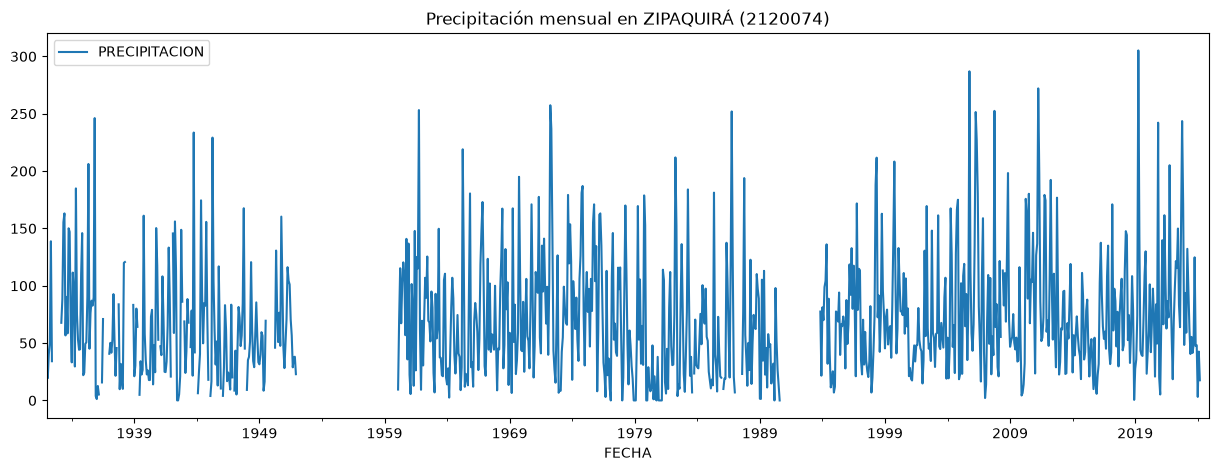

In [7]:
prec.plot(x='FECHA', y='PRECIPITACION', figsize=(15, 5), title='Precipitación mensual en ' + nombre + ' (' + str(codigo) + ')')

También podemos fácilmente calcular el promedio mensual de precipitaciones y obtener las primeras evidencias de estacionalidad

([<matplotlib.axis.XTick at 0x2155d9a5bd0>,
 [Text(0, 0, 'Enero'),
  Text(1, 0, 'Febrero'),
  Text(2, 0, 'Marzo'),
  Text(3, 0, 'Abril'),
  Text(4, 0, 'Mayo'),
  Text(5, 0, 'Junio'),
  Text(6, 0, 'Julio'),
  Text(7, 0, 'Agosto'),
  Text(8, 0, 'Septiembre'),
  Text(9, 0, 'Octubre'),
  Text(10, 0, 'Noviembre'),
  Text(11, 0, 'Diciembre')])

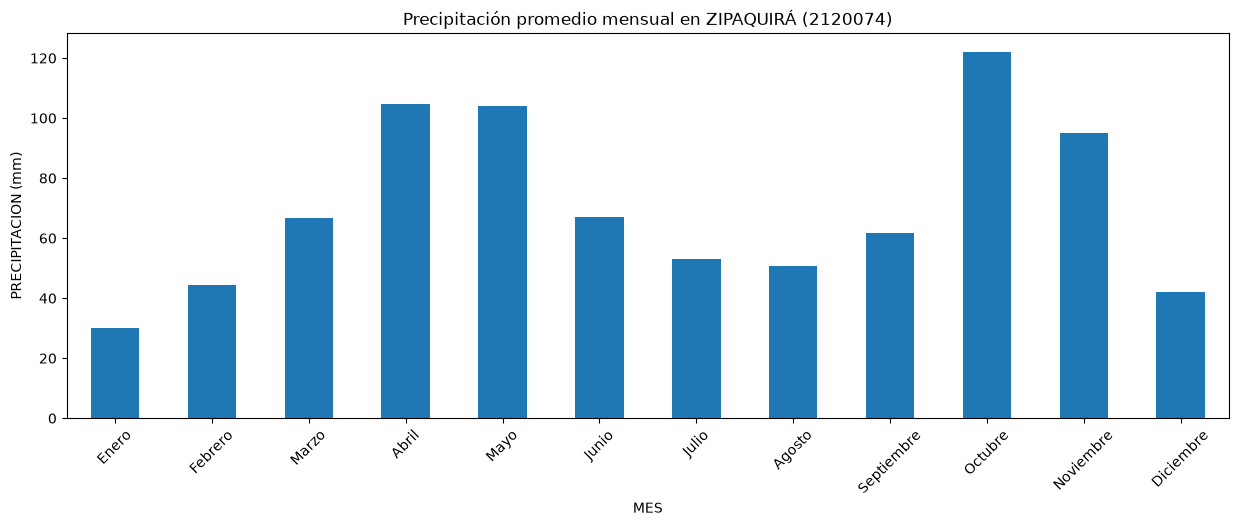

In [8]:
prec.groupby('MES')['PRECIPITACION'].mean().plot(kind='bar', figsize=(15, 5), title='Precipitación promedio mensual en ' + nombre + ' (' + str(codigo) + ')', xlabel='MES', ylabel='PRECIPITACION (mm)')
plt.xticks(ticks=range(12), labels=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'], rotation=45)

Como se observa, para esta estación hay 2 temporadas de lluvias anualmente, una entre Abril-Mayo y otra entre Octubre-Noviembre. De la misma manera Diciembre-Enero-Febrero y Julio-Agosto son temporadas en las que típicamente hay menos lluvias.

Finalmente agregamos la información de la estación para finalizar la creación de la base de datos

In [9]:
prec['NOMBRE'] = nombre # agregar el nombre de la estación a los datos
prec['CODIGO'] = codigo # agregar el código de la estación a los datos 
prec['LONGITUD'] = longitud # agregar la longitud a los datos
prec['LATITUD'] = latitud # agregar la latitud a los datos
prec['MUNICIPIO'] = municipio # agregar el municipio a los datos
prec['CUENCA'] = cuenca # agregar la cuenca a los datos

prec

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,MUNICIPIO,CUENCA
0,1932,1,59.8,1932-01,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
83,1932,2,19.4,1932-02,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
166,1932,3,40.3,1932-03,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
249,1932,4,49.6,1932-04,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
332,1932,5,138.8,1932-05,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
...,...,...,...,...,...,...,...,...,...,...
663,2024,8,NaN,2024-08,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
746,2024,9,NaN,2024-09,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
829,2024,10,NaN,2024-10,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO
912,2024,11,NaN,2024-11,ZIPAQUIRÁ,2120074,5.01,74.0,ZIPAQUIRA,R. NEGRO


Finalmente podemos entonces crear una función para importar los datos de una hoja específica del archivo y haga el mismo ejercicio que acabamos de hacer

In [13]:
# creando una función para importar los datos de precipitación de una hoja del excel
def obtener_precipitaciones(hoja_id):
    # primera importación, obteniendo datos de la estación
    info_data = pd.read_excel('data/HISTÓRICO DE PRECIPITACIONES MENSUALES.xlsx', sheet_name=hoja_id)
    # Extrayendo longitud y latitud
    longitud = float(re.search(r'\d+', info_data.iloc[6,1]).group()) / 100 
    latitud = float(re.search(r'\d+', info_data.iloc[7,1]).group()) / 100 

    # código y nombre de la estación
    codigo = int(re.search(r'\d+', info_data.iloc[4,17]).group()) # buscamos un número en el texto
    nombre = info_data.iloc[4,17].split(str(codigo))[1].strip() # el nombre está después del código

    # leer los datos de la hoja
    prec_data = pd.read_excel('data/HISTÓRICO DE PRECIPITACIONES MENSUALES.xlsx', sheet_name=hoja_id, header=12)

    # Eliminar columnas y filas vacías
    prec_data = prec_data.dropna(axis=1, how='all')
    prec_data = prec_data.dropna(axis=0, how='all')

    # convertir a formato largo
    prec = prec_data.melt(id_vars=['AÑO'], var_name='MES', value_name='PRECIPITACION')

    # reemplazar los nombres de los meses por números
    prec['MES'] = prec['MES'].map({'ENERO': 1, 'FEBRE': 2, 'MARZO': 3, 'ABRIL': 4, 'MAYO': 5, 'JUNIO': 6,
                                       'JULIO': 7, 'AGOST': 8, 'SEPTI': 9, 'OCTUB': 10, 'NOVIE': 11, 'DICIE': 12})

    # convertir la columna de año y mes a un periodo de datetime
    prec['AÑO'] = prec['AÑO'].astype(int) # asegurarse de que el año sea un entero
    prec['FECHA'] = pd.to_datetime(prec['AÑO'].astype(str) + '-' + prec['MES'].astype(str), format='%Y-%m').dt.to_period('M')

    # convertir la columna de precipitación a un número, usando la , como separador decimal
    prec['PRECIPITACION'] = prec['PRECIPITACION'].astype(str).str.replace(',', '.') # reemplazar la , por un .
    prec['PRECIPITACION'] = pd.to_numeric(prec['PRECIPITACION'], errors='coerce', ) # convertir a numérico, forzando errores a NaN

    # ordenando los datos por fecha
    prec = prec.sort_values(by='FECHA')

    # agregar los datos de la estación
    prec['NOMBRE'] = nombre # agregar el nombre de la estación a los datos
    prec['CODIGO'] = codigo # agregar el código de la estación a los datos
    prec['LONGITUD'] = longitud # agregar la longitud a los datos
    prec['LATITUD'] = latitud # agregar la latitud a los datos

    # devolver el dataframe
    return prec

Probemos nuestra función

In [14]:
obtener_precipitaciones('2120074') # probando la función

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD
0,1932,1,59.8,1932-01,ZIPAQUIRÁ,2120074,5.01,74.0
83,1932,2,19.4,1932-02,ZIPAQUIRÁ,2120074,5.01,74.0
166,1932,3,40.3,1932-03,ZIPAQUIRÁ,2120074,5.01,74.0
249,1932,4,49.6,1932-04,ZIPAQUIRÁ,2120074,5.01,74.0
332,1932,5,138.8,1932-05,ZIPAQUIRÁ,2120074,5.01,74.0
...,...,...,...,...,...,...,...,...
663,2024,8,NaN,2024-08,ZIPAQUIRÁ,2120074,5.01,74.0
746,2024,9,NaN,2024-09,ZIPAQUIRÁ,2120074,5.01,74.0
829,2024,10,NaN,2024-10,ZIPAQUIRÁ,2120074,5.01,74.0
912,2024,11,NaN,2024-11,ZIPAQUIRÁ,2120074,5.01,74.0


Ahora si estamos listos para cargar la totalidad de la información, y consolidar todo en un único DataFrame. Pero antes, necesitamos obtener un listado de las hojas de Excel presentes en el archivo. Esto se obtiene fácilmente con pandas

In [15]:
# Obtener los nombres de las hojas del excel
hojas = pd.ExcelFile('data/HISTÓRICO DE PRECIPITACIONES MENSUALES.xlsx').sheet_names # obteniendo los nombres de las hojas
print(hojas) # imprimiendo los nombres de las hojas
print(len(hojas)) # imprimiendo la cantidad de hojas

['2120074', '2401051', '2120046', '2120637', '3509508', '2120043', '2120188', '2120640', '2120693', '2120026', '2120629', '2120057', '2120111', '2119514', '2120055', '2120185', '2401039', '2401044', '3509506', '2120077', '3506029', '2120104', '2120631', '2120094', '2120069', '2120636', '2401028', '2401535', '2120565', '2401521', '2401029', '2120103', '2401046', '3502019', '2312012', '2120787', '2120563', '2120176', '2120136', '2401040', '2120073', '2120014', '2401037', '2401513', '2120151', '2120719', '2120027', '2401531', '2401032', '2120080', '2120172', '2306034', '2120180', '2120921', '2120088', '2120659', '2120539', '2120171', '2401537', '2401534', '2120541', '2401034', '2401538', '2120516', '2401516', '3502017', '2401038', '2120696', '2120557', '2120766', '2120044', '2120181', '3509505', '2119026', '2120691', '2123502', '2401116', '2312019', '2401027', '2401716', '2120156', '2120182', '2120178', '2401049', '2120134', '2120634', '2120652', '2119714', '2119022', '3509504', '2401519'

Como vemos, tenemos 219 estaciones hidrológicas diferentes (la última hoja no contiene información). Procedamos entonces a cargar la información de todas ellas y agregarla a un dataframe consolidado.

In [16]:
# creamos un dataframe vacío para almacenar los datos de todas las estaciones
prec_all = pd.DataFrame() # creando un dataframe vacío
# iteramos sobre las hojas del excel, obteniendo los datos de cada estación
for hoja in tqdm(hojas[:-1]):
    # obteniendo los datos de la estación
    prec = obtener_precipitaciones(hoja) # obteniendo los datos de la estación
    # concatenando los datos al dataframe vacío
    prec_all = pd.concat([prec_all, prec], ignore_index=True) # concatenando los datos al dataframe vacío

100%|██████████| 219/219 [05:19<00:00,  1.46s/it]


Veamos el resultado:

In [17]:
prec_all

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD
0,1932,1,59.8,1932-01,ZIPAQUIRÁ,2120074,5.01,74.00
1,1932,2,19.4,1932-02,ZIPAQUIRÁ,2120074,5.01,74.00
2,1932,3,40.3,1932-03,ZIPAQUIRÁ,2120074,5.01,74.00
3,1932,4,49.6,1932-04,ZIPAQUIRÁ,2120074,5.01,74.00
4,1932,5,138.8,1932-05,ZIPAQUIRÁ,2120074,5.01,74.00
...,...,...,...,...,...,...,...,...
83918,2024,8,NaN,2024-08,ACANDY,2120141,5.03,73.53
83919,2024,9,NaN,2024-09,ACANDY,2120141,5.03,73.53
83920,2024,10,NaN,2024-10,ACANDY,2120141,5.03,73.53
83921,2024,11,NaN,2024-11,ACANDY,2120141,5.03,73.53


Revisemos información de cuántos años, de cuántas estaciones, de cuántos municipios y de cuántas cuencas hay:

In [18]:
print("El número de estaciones: ", prec_all['CODIGO'].nunique())
print("El número de años: ", prec_all['AÑO'].nunique())

El número de estaciones:  219
El número de años:  96


Podemos rápidamente graficar cuántos datos hay para cada año usando la función `groupby` con la función de agregación `count()` que simplemente cuenta cuántas ocurrencias hay. Esta información es importante porque nos da una idea de la significancia de los datos, los años con un número muy pequeño de datos probablemente no den una información muy adecuada.

<Axes: title={'center': 'Número de observaciones por año'}, xlabel='AÑO', ylabel='Número de observaciones por año'>

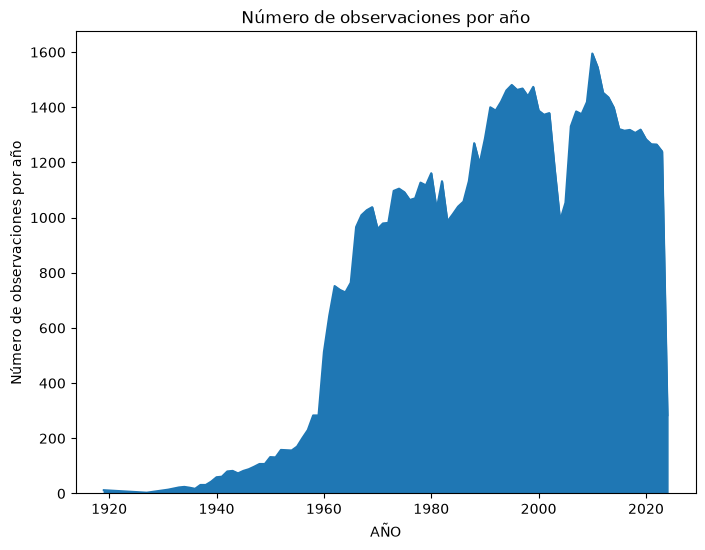

In [19]:
prec_all.groupby('AÑO')['PRECIPITACION'].count().plot(kind = 'area', figsize = (8,6), legend = False, ylabel = 'Número de observaciones por año', title = 'Número de observaciones por año')

Note cómo hemos introducido el argumento `kind` dentro de plot para convertirla en una figura tipo *area*. 

En este punto, y para uso posterior, guardaremos nuestra base de datos modificada y unificada.

In [ ]:
prec_all.to_csv('data/base_precipitaciones_unificada.csv', index = False)

### Revisando la serie de tiempo de precipitaciones para una estación específica

Para hacer un ejemplo, revisemos cuáles estaciones tienen la mayor cantidad de datos en nuestra base de datos

In [20]:
prec_all.groupby(['NOMBRE','CODIGO'])['AÑO'].agg(['count','nunique']).sort_values(by=['count', 'nunique'], ascending=False).head(50) # mostrando las 10 estaciones con más datos

,,count,nunique
NOMBRE,CODIGO,,
RAMADA LA,2120516,1032,86
ZIPAQUIRÁ,2120074,996,83
TESORO,2120069,936,78
GUATAVITA,2120562,924,77
ISLA DEL SANTUARIO,2401110,900,75
CHECUA,2120540,864,72
SALITRE EL,2120088,828,69
VENECIA,2120629,828,69
PRADERA LA,2120044,804,67


Veamos ahora cómo podemos filtrar los datos para tener en cuenta únicamente los resultados de la estación llamada *RAMADA LA*. El truco es definir un listado de números booleanos que sea False para las filas que no queremos usar y sea True para las filas que sí queremos. Este listado se denomina máscara y se define de la manera siguiente:

<Axes: title={'center': 'Precipitación mensual en La Ramada'}, xlabel='FECHA'>

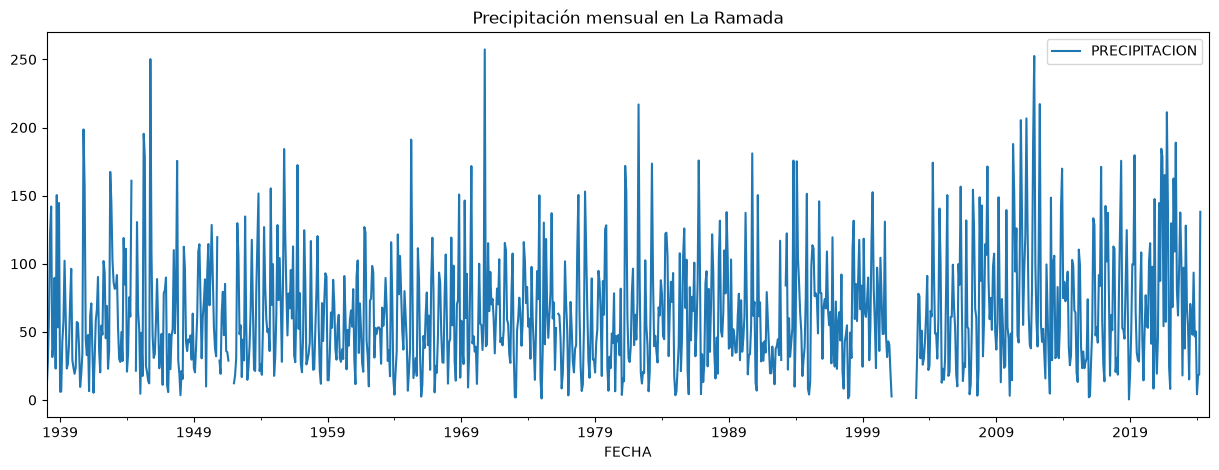

In [21]:
# Definimos una máscara
mask = prec_all['CODIGO'] == 2120516
# Filtramos el dataframe usando la máscara
prec_all[mask].plot(x='FECHA', y='PRECIPITACION', figsize=(15, 5), title='Precipitación mensual en La Ramada')

Efectivamente nos quedamos sólo con los datos correspondientes a *LA RAMADA*. Ahora vamos a crear un nuevo DataFrame sólo con esta nueva información:

In [22]:
ramada_data = prec_all[mask].reset_index(drop=True)
ramada_data

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD
0,1938,1,8.9,1938-01,RAMADA LA,2120516,4.43,74.11
1,1938,2,27.3,1938-02,RAMADA LA,2120516,4.43,74.11
2,1938,3,60.4,1938-03,RAMADA LA,2120516,4.43,74.11
3,1938,4,122.5,1938-04,RAMADA LA,2120516,4.43,74.11
4,1938,5,142.0,1938-05,RAMADA LA,2120516,4.43,74.11
...,...,...,...,...,...,...,...,...
1027,2024,8,NaN,2024-08,RAMADA LA,2120516,4.43,74.11
1028,2024,9,NaN,2024-09,RAMADA LA,2120516,4.43,74.11
1029,2024,10,NaN,2024-10,RAMADA LA,2120516,4.43,74.11
1030,2024,11,NaN,2024-11,RAMADA LA,2120516,4.43,74.11


Veamos cómo se ve la serie de datos de precipitaciones en esta estación a lo largo del tiempo:

___
#### Ejercicio 1
Grafique la serie de tiempo de precipitaciones mensuales para la estación hidrológica llamada *La Ramada*.
___

Veamos por ejemplo cómo es el histograma general de precipitaciones mensuales para la estación hidrológica:

Text(0, 0.5, 'número de ocurrencias')

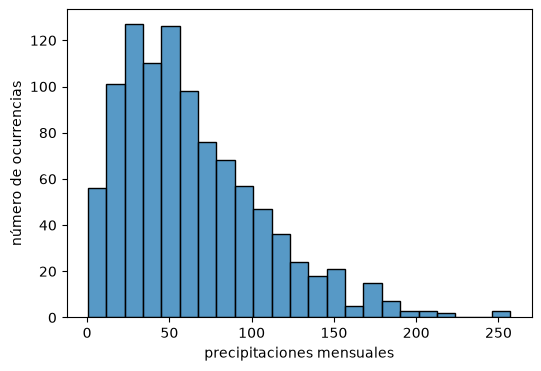

In [23]:
fig, axs = plt.subplots(figsize = (6,4))
sns.histplot(data = ramada_data, x='PRECIPITACION')  # creando un histograma a partir de las precipitaciones mensuales con seaborn
axs.set_xlabel('precipitaciones mensuales')
axs.set_ylabel('número de ocurrencias')

Aquí hemos usado por primera vez la librería *seaborn* para hacer gráficos. Esta librería incluye nuevos tipos de gráfica que son muy utilizados en estadística y ciencia de datos para mostrar la información proveniente de bases de datos muy grandes. Además, la librería *seaborn* permite usar contextos predefinidos para dar a las gráficas un *look* determinado de forma muy rápida y eficiente.

Text(24.33658854166668, 0.5, 'número de ocurrencias')

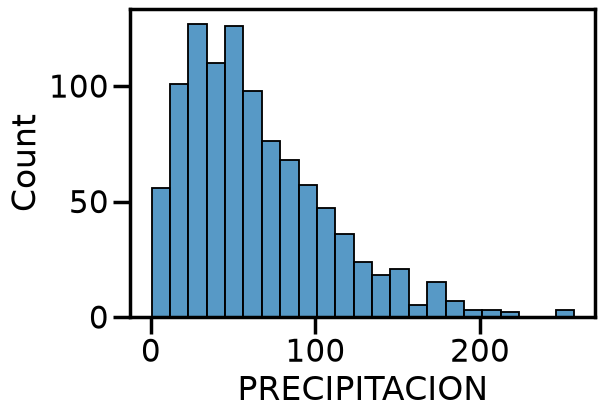

In [24]:
sns.set_context('poster')
fig, ax = plt.subplots(figsize = (6,4))
sns.histplot(data = ramada_data, x='PRECIPITACION')  # creando un histograma a partir de las precipitaciones mensuales con seaborn
axs.set_xlabel('precipitaciones mensuales')
axs.set_ylabel('número de ocurrencias')

Text(0, 0.5, 'número de ocurrencias')

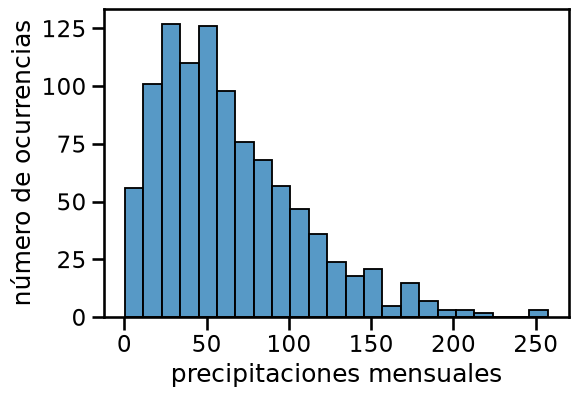

In [25]:
sns.set_context('talk')
fig, axs = plt.subplots(figsize = (6,4))
sns.histplot(data = ramada_data, x='PRECIPITACION')  # creando un histograma a partir de las precipitaciones mensuales con seaborn
axs.set_xlabel('precipitaciones mensuales')
axs.set_ylabel('número de ocurrencias')


Text(0, 0.5, 'número de ocurrencias')

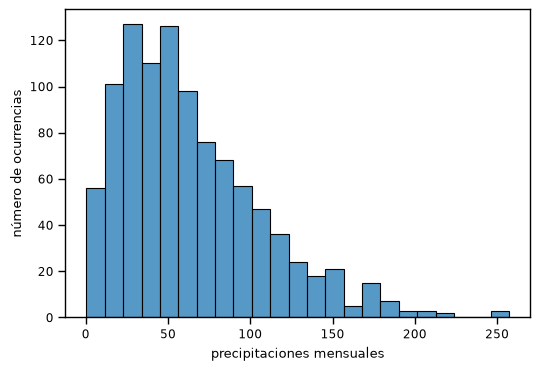

In [26]:
sns.set_context('paper')
fig, axs = plt.subplots(figsize = (6,4))
sns.histplot(data = ramada_data, x='PRECIPITACION')  # creando un histograma a partir de las precipitaciones mensuales con seaborn
axs.set_xlabel('precipitaciones mensuales')
axs.set_ylabel('número de ocurrencias')

Más información sobre el uso de Seaborn y sus opciones se puede encontrar en su documentación oficial:

- https://seaborn.pydata.org/index.html 

Como se observa, la distribución de precipitaciones mensuales es muy ancha y de hecho el conteo más usual es el de muy bajas precipitaciones. Veamos qué ocurre ahora cuando graficamos el histograma de precipitaciones para cada uno de los meses del año. Esto lo podemos hacer con ayuda de un violinplot:

<Axes: xlabel='MES', ylabel='PRECIPITACION'>

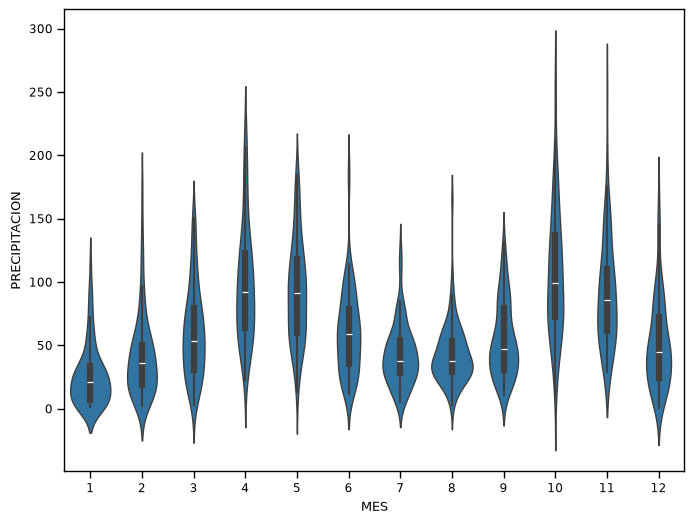

In [27]:
fig, axs = plt.subplots(figsize = (8,6))
sns.violinplot(data = ramada_data, x='MES', y ='PRECIPITACION')


En el *violinplot* los datos se muestran como una gráfica aproximada de su distribución, el punto identifica la mediana de los datos, y las barras internas corresponden al rango en el que se encuentran el 50% de los datos alrededor de la mediana. Usualmente el eje *x* en este tipo de gráficas corresponde a una **variable categórica** que en este caso es el mes.


Otra gráfica similar es la conocida como *boxblot*.

¿Cómo se debe interpretar un boxplot? 

* La linea central representa la mediana, es decir, el valor para el cuál el 50% de los datos están por encima y el 50% de los datos está por debajo.
* La caja representa los cuadriles Q1 y Q3, de manera que dentro de la caja están el 50% de los datos.
* Los bigotes se extienden hasta cubrir la totalidad de los datos, pero no pueden superar una longitud mayor a 1.5 *IQR* en donde *IQR* (inter quartile range). Como se muestra en la figura, para una distribución normal se espera que el 99.3% de los datos esté dentro de los bigotes.
* Los puntos que quedan fuera de los bigotes se denominan *outliers*.
* En este caso, hemos incluído también los valores promedio, como triángulos verdes.

![Boxplot](fig/boxplot.png)


Imagen tomada de https://en.wikipedia.org/wiki/Box_plot#/media/File:Boxplot_vs_PDF.svg, con licencia  [CC BY-SA 2.5.](https://creativecommons.org/licenses/by-sa/2.5/)




<Axes: xlabel='MES', ylabel='PRECIPITACION'>

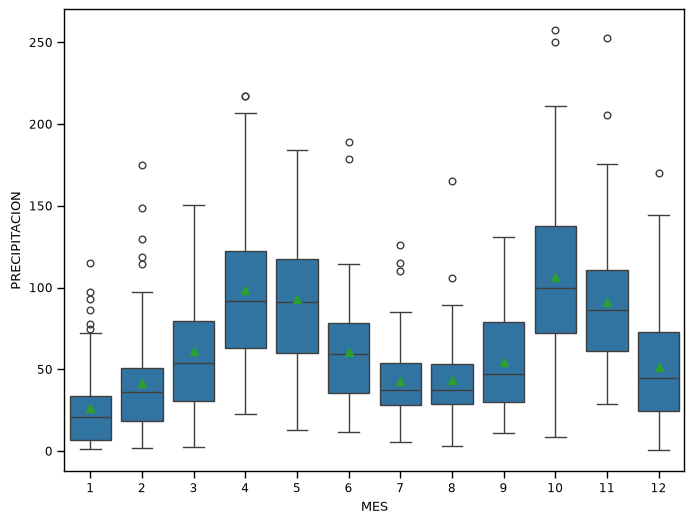

In [28]:
fig, axs = plt.subplots(figsize = (8,6))

sns.boxplot(data = ramada_data, x='MES', y ='PRECIPITACION', showmeans = True)

Podemos anotar varios puntos importantes con respecto a esta gráfica:

* La estación hidrológica sisga no muestra una tendencia de 2 estaciones en el año, sino solo 1, para la cual el máximo de lluvias se da en los meses de Junio y Julio. 
* Para cada mes, hay una muy alta asimetría en los niveles de precipitación. Esta asimetría es evidente por la diferencia en la longitud de los bigotes a lado y lado de cada caja y también por la diferencia entre la mediana y el promedio.

La asimetría de las distribuciones es un problema porque nos hace más sensibles a las temporadas lluviosas que a las temporadas secas. De manera que es importante buscar una transformación de los datos que resulte en distribuciones más simétricas. En este caso, haremos el análisis al usar nuestros datos originales y el mismo análisis con una transformación apropiada, en este caso, tomaremos la raíz cuadrada de las precipitaciones. Veamos:

In [29]:
ramada_data['prec_trans'] = np.sqrt(ramada_data['PRECIPITACION']) # transformando la variable de precipitaciones
ramada_data.head(10)

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans
0,1938,1,8.9,1938-01,RAMADA LA,2120516,4.43,74.11,2.983287
1,1938,2,27.3,1938-02,RAMADA LA,2120516,4.43,74.11,5.224940
2,1938,3,60.4,1938-03,RAMADA LA,2120516,4.43,74.11,7.771744
3,1938,4,122.5,1938-04,RAMADA LA,2120516,4.43,74.11,11.067972
4,1938,5,142.0,1938-05,RAMADA LA,2120516,4.43,74.11,11.916375
5,1938,6,31.5,1938-06,RAMADA LA,2120516,4.43,74.11,5.612486
6,1938,7,40.0,1938-07,RAMADA LA,2120516,4.43,74.11,6.324555
7,1938,8,89.6,1938-08,RAMADA LA,2120516,4.43,74.11,9.465728
8,1938,9,23.1,1938-09,RAMADA LA,2120516,4.43,74.11,4.806246
9,1938,10,150.4,1938-10,RAMADA LA,2120516,4.43,74.11,12.263768


Text(0, 0.5, 'raiz cuadrada de precipitaciones')

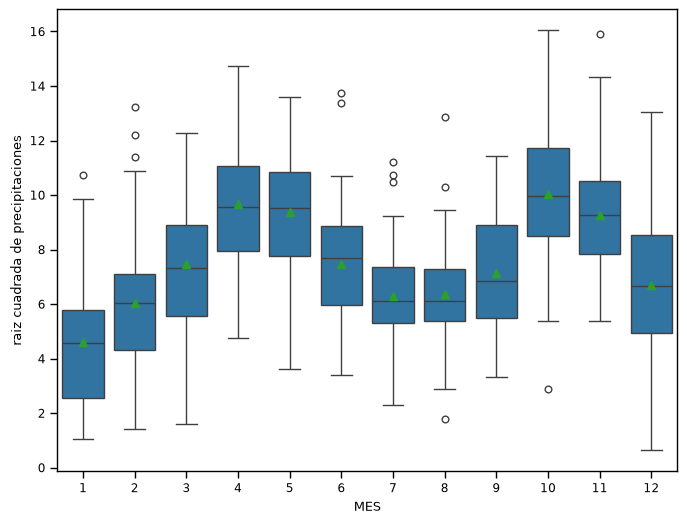

In [30]:
fig, axs = plt.subplots(figsize = (8,6))

sns.boxplot(data = ramada_data[['MES','prec_trans']], x='MES', y ='prec_trans', showmeans=True)
axs.set_ylabel('raiz cuadrada de precipitaciones')

Como se observa, usar la raiz cuadrada de las precipitaciones resulta en distribuciones mucho más simétricas y en una mayor cercanía de la mediana con el promedio. Esto le mejorará el alcance a nuestro análisis estadístico.

Aunque no lo usamos aquí, existe también un método estadístico para determinar cuál es la mejor transformación posible de un conjunto de datos para hacer la distribución simétrica. Este proceso de llama transformación Box-Cox y puede implementarse muy fácilmente usando la libreria SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html 



___
#### Ejercicio 2
Realice un boxplot que muestre el perfil de precipitaciones mes a mes para la estación hidrológica *SISGA*, ¿qué diferencia observa con respecto al perfil previamente discutido para la estación *LA RAMADA*?
___

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD
0,1952,1,19.3,1952-01,REPRESA SISGA,2120171,5.05,73.44
1,1952,2,18.0,1952-02,REPRESA SISGA,2120171,5.05,73.44
2,1952,3,3.4,1952-03,REPRESA SISGA,2120171,5.05,73.44
3,1952,4,17.5,1952-04,REPRESA SISGA,2120171,5.05,73.44
4,1952,5,54.3,1952-05,REPRESA SISGA,2120171,5.05,73.44
...,...,...,...,...,...,...,...,...
607,2019,8,NaN,2019-08,REPRESA SISGA,2120171,5.05,73.44
608,2019,9,NaN,2019-09,REPRESA SISGA,2120171,5.05,73.44
609,2019,10,NaN,2019-10,REPRESA SISGA,2120171,5.05,73.44
610,2019,11,NaN,2019-11,REPRESA SISGA,2120171,5.05,73.44


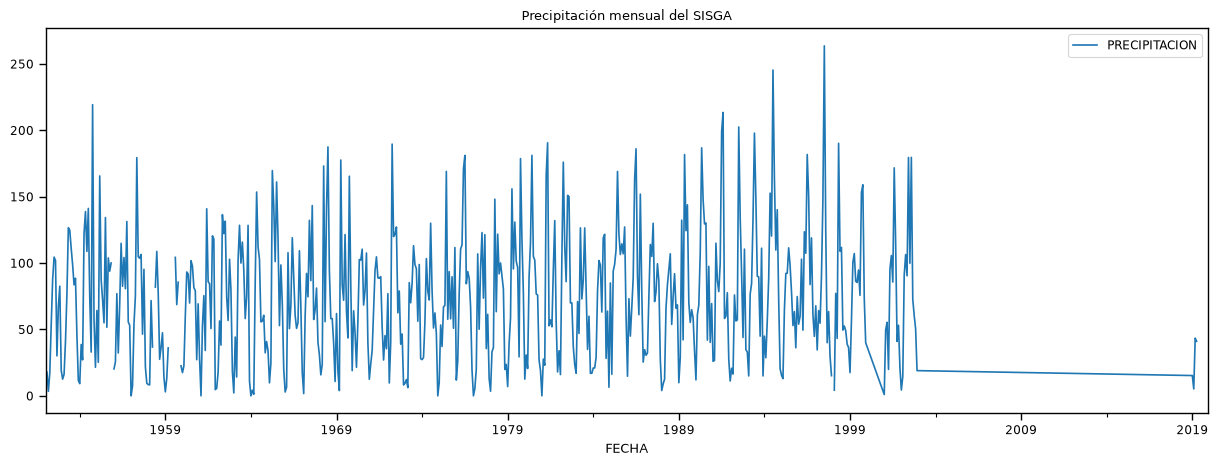

In [37]:
mask = prec_all['CODIGO'] == 2120171
# Filtramos el dataframe usando la máscara
prec_all[mask].plot(x='FECHA', y='PRECIPITACION', figsize=(15, 5), title='Precipitación mensual del SISGA')


sisga_data = prec_all[mask].reset_index(drop=True)
sisga_data

Text(0, 0.5, 'número de ocurrencias')

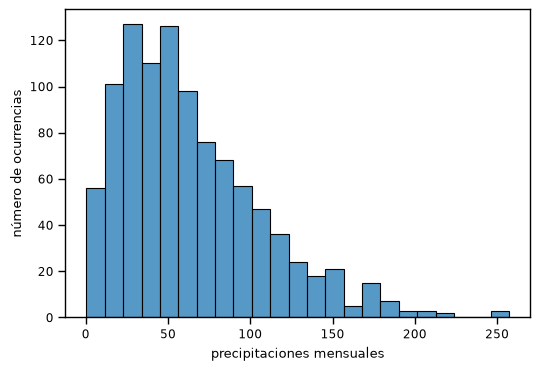

In [38]:
fig, axs = plt.subplots(figsize = (6,4))
sns.histplot(data = sisga_data, x='PRECIPITACION')  # creando un histograma a partir de las precipitaciones mensuales con seaborn
axs.set_xlabel('precipitaciones mensuales')
axs.set_ylabel('número de ocurrencias')

<Axes: xlabel='MES', ylabel='PRECIPITACION'>

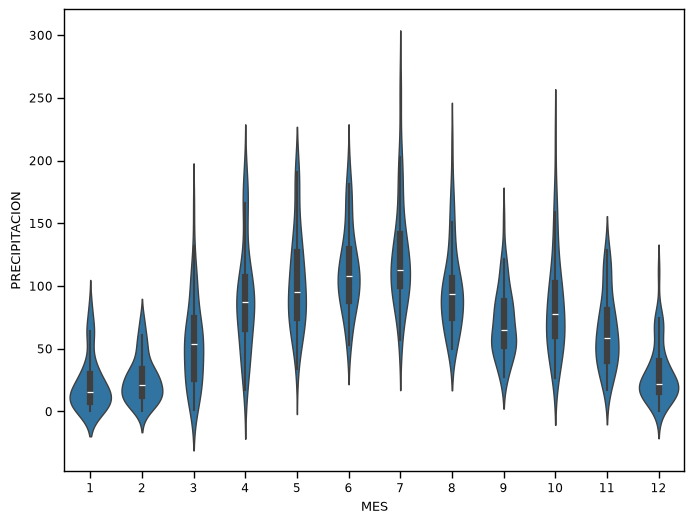

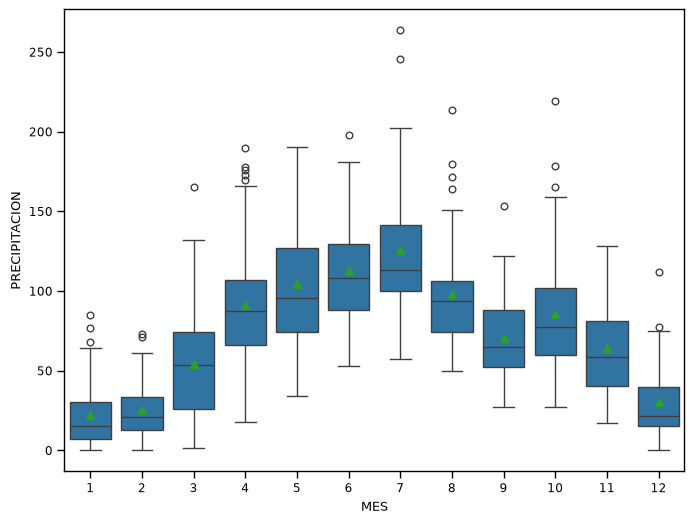

In [40]:
fig, axs = plt.subplots(figsize = (8,6))
sns.violinplot(data = sisga_data, x='MES', y ='PRECIPITACION')

fig, axs = plt.subplots(figsize = (8,6))
sns.boxplot(data = sisga_data, x='MES', y ='PRECIPITACION', showmeans = True)

### Respuesta Ejercicio 2 — SISGA vs LA RAMADA

La diferencia principal es el **número de temporadas de lluvia al año**:

- **La Ramada** tiene un perfil **bimodal**: dos temporadas lluviosas separadas — una en **abril-mayo** (~99 y 93 mm) y otra en **octubre-noviembre** (~107 y 91 mm) — con dos periodos secos entre ellas (enero-febrero y junio-julio). Es el patrón típico de la región andina de Cundinamarca.
- **El Sisga** tiene un perfil **unimodal**: una sola temporada lluviosa larga a **mitad de año**, con el máximo claro en **julio** (~126 mm) y elevada de mayo a agosto, y una única temporada seca a comienzos y fin de año (diciembre-enero-febrero, ~22-31 mm).

En resumen, mientras La Ramada reparte la lluvia en dos picos anuales, el Sisga la concentra en un solo pico a mitad de año. El criterio de estacionalidad (promedio por mes) debe capturar formas muy distintas según la estación.

La diferencia principal es el número de temporadas de lluvia al año:

1. La Ramada tiene un perfil bimodal: dos temporadas lluviosas separadas — una en abril-mayo (~99 y 93 mm) y otra en octubre-noviembre (~107 y 91 mm) — con dos periodos secos entre ellas (enero-febrero y junio-julio). Es el patrón típico de la región andina de Cundinamarca.
2. El Sisga tiene un perfil unimodal: una sola temporada lluviosa larga a mitad de año, con el máximo claro en julio (~126 mm) y elevada de mayo a agosto, y una única temporada seca a comienzos y fin de año (diciembre-enero-febrero, ~22-31 mm).
En resumen, mientras La Ramada reparte la lluvia en dos picos anuales, el Sisga la concentra en un solo pico a mitad de año. Esto es importante para el análisis de anomalías, porque el criterio de estacionalidad (el promedio por mes) debe capturar formas muy distintas según la estación.

___
#### Ejercicio 3
Realice el boxplot con el perfil de precipitaciones para la estación *EL SISGA*, pero esta vez transforme las precipitaciones usando la función raíz cuadrada. ¿Se obtienen también en este caso distribuciones más simétricas?
___

In [43]:
sisga_data['prec_trans'] = np.sqrt(sisga_data['PRECIPITACION']) # transformando la variable de precipitaciones
sisga_data.head(10)

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans
0,1952,1,19.3,1952-01,REPRESA SISGA,2120171,5.05,73.44,4.393177
1,1952,2,18.0,1952-02,REPRESA SISGA,2120171,5.05,73.44,4.242641
2,1952,3,3.4,1952-03,REPRESA SISGA,2120171,5.05,73.44,1.843909
3,1952,4,17.5,1952-04,REPRESA SISGA,2120171,5.05,73.44,4.183300
4,1952,5,54.3,1952-05,REPRESA SISGA,2120171,5.05,73.44,7.368853
5,1952,6,87.8,1952-06,REPRESA SISGA,2120171,5.05,73.44,9.370165
6,1952,7,104.5,1952-07,REPRESA SISGA,2120171,5.05,73.44,10.222524
7,1952,8,101.9,1952-08,REPRESA SISGA,2120171,5.05,73.44,10.094553
8,1952,9,30.1,1952-09,REPRESA SISGA,2120171,5.05,73.44,5.486347
9,1952,10,67.3,1952-10,REPRESA SISGA,2120171,5.05,73.44,8.203658


### Respuesta Ejercicio 3 — ¿la raíz cuadrada simetriza también al Sisga?

**Sí, la transformación con raíz cuadrada también produce distribuciones más simétricas en el Sisga**, aunque el efecto es algo menor que en La Ramada porque el Sisga partía de menos asimetría:

| | Asimetría (skew) cruda | Asimetría con sqrt | Media / Mediana cruda | Media / Mediana sqrt |
|---|---|---|---|---|
| La Ramada | +1.10 | +0.19 | 64.1 / 54.0 | 7.53 / 7.35 |
| **Sisga** | **+0.67** | **-0.26** | **73.6 / 69.9** | **8.04 / 8.36** |

En los datos crudos la media es mayor que la mediana (cola larga hacia la derecha, típico de la lluvia). Tras aplicar sqrt, media y mediana se acercan mucho y la asimetría cae de +0.67 a casi cero. La transformación se "pasa" un poco en el Sisga y deja una leve asimetría negativa (-0.26), pero la distribución queda bastante más simétrica que la original, igual que con La Ramada. Conclusión: sqrt mejora la simetría y acerca mediana y promedio, lo que hace más confiable el análisis posterior (z-score).

Text(0, 0.5, 'raiz cuadrada de precipitaciones')

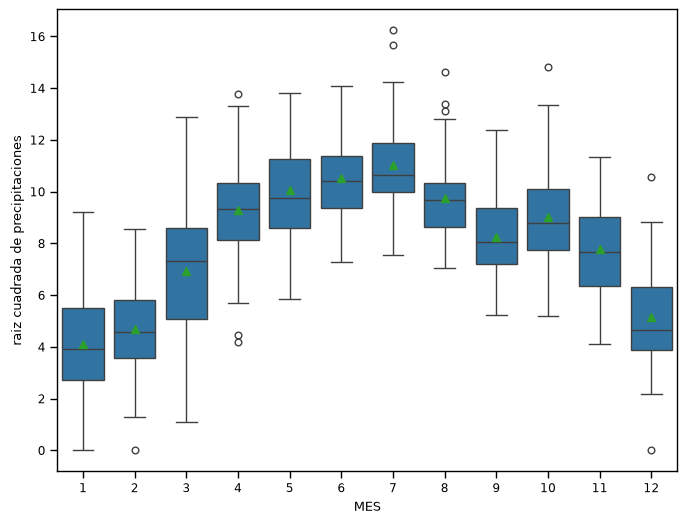

In [44]:
fig, axs = plt.subplots(figsize = (8,6))

sns.boxplot(data = sisga_data[['MES','prec_trans']], x='MES', y ='prec_trans', showmeans=True)
axs.set_ylabel('raiz cuadrada de precipitaciones')

Sí, la transformación con raíz cuadrada también produce distribuciones más simétricas en el Sisga, aunque el efecto es un poco menor que en La Ramada porque el Sisga partía de menos asimetría

| Estación / Ubicación | Asimetría (skew) cruda | Asimetría con sqrt | Media / Mediana cruda | Media / Mediana sqrt |
| :--- | :---: | :---: | :---: | :---: |
| **La Ramada** | +1.10 | +0.19 | 64.1 / 54.0 | 7.53 / 7.35 |
| **Sisga** | +0.67 | −0.26 | 73.6 / 69.9 | 8.04 / 8.36 |

En los datos crudos la media es mayor que la mediana (cola larga hacia la derecha, típico de la lluvia). Tras aplicar sqrt, la media y la mediana se acercan mucho y la asimetría cae de +0.67 a casi cero. La única diferencia es que en el Sisga la transformación se "pasa" un poco y deja una leve asimetría negativa (−0.26), pero en la práctica la distribución queda bastante más simétrica que la original, igual que ocurrió con La Ramada. Por lo tanto, la conclusión es la misma: sqrt mejora la simetría y acerca mediana y promedio, lo que hace más confiable el análisis estadístico posterior (z-score).

### Obtención de la componente estacional

En el caso anterior hicimos análisis de descomposición de series usando el paquete `seasonal_decompose` de `statsmodels`. En este caso usaremos una aproximación un poco menos directa por dos razones:

- La tendencia de esta serie de tiempo debe ser 0, ya que no se espera que las precipitaciones, como un promedio, tiendan a aumentar o disminuir en el tiempo. Cualquier variación entonces será observada en el residuo.

- Hay datos, e incluso años faltantes, la descomposición asume que tenemos una serie de datos continuos.

Enfocaremos nuestro análisis en los datos modificados. Para empezar, crearemos dos nuevas columnas con el promedio y la desviación estándar de las precipitaciones para cada mes:

In [31]:
# creando una nueva columna con el promedio de precipitaciones por mes
ramada_data['prom_prec'] = ramada_data.groupby('MES')['prec_trans'].transform('mean') # creando una nueva columna con el promedio de precipitaciones por mes
# creando una nueva columna con las desviación estándar de las precipitaciones por mes
ramada_data['std_prec'] = ramada_data.groupby('MES')['prec_trans'].transform('std') # creando una nueva columna con las desviación estándar de las precipitaciones por mes

ramada_data

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans,prom_prec,std_prec
0,1938,1,8.9,1938-01,RAMADA LA,2120516,4.43,74.11,2.983287,4.620462,2.263486
1,1938,2,27.3,1938-02,RAMADA LA,2120516,4.43,74.11,5.224940,6.025912,2.350817
2,1938,3,60.4,1938-03,RAMADA LA,2120516,4.43,74.11,7.771744,7.455684,2.356157
3,1938,4,122.5,1938-04,RAMADA LA,2120516,4.43,74.11,11.067972,9.670575,2.254093
4,1938,5,142.0,1938-05,RAMADA LA,2120516,4.43,74.11,11.916375,9.392640,2.124379
...,...,...,...,...,...,...,...,...,...,...,...
1027,2024,8,NaN,2024-08,RAMADA LA,2120516,4.43,74.11,NaN,6.362440,1.669696
1028,2024,9,NaN,2024-09,RAMADA LA,2120516,4.43,74.11,NaN,7.126659,1.975123
1029,2024,10,NaN,2024-10,RAMADA LA,2120516,4.43,74.11,NaN,10.028348,2.458623
1030,2024,11,NaN,2024-11,RAMADA LA,2120516,4.43,74.11,NaN,9.282405,2.201657


Veamos gráficamente el resultado

(np.float64(16436.0), np.float64(19723.0))

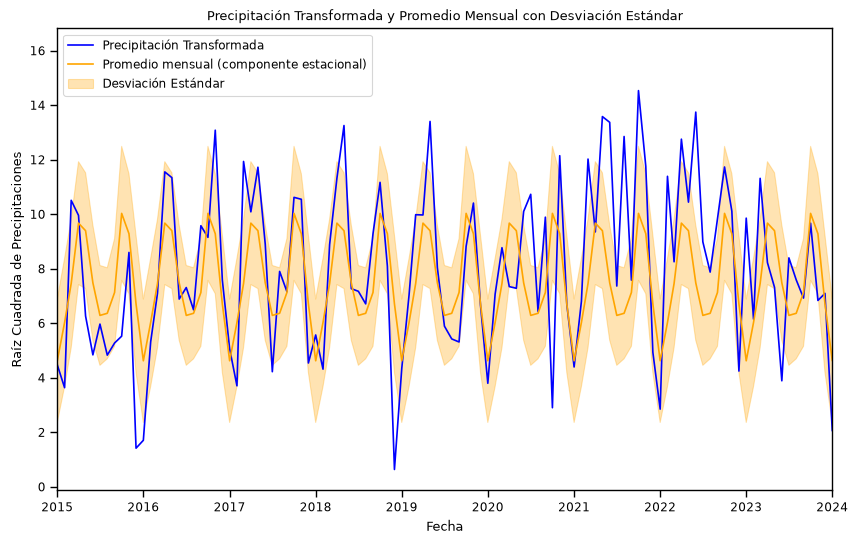

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

# Graficando la precipitación transformada
ax.plot(ramada_data['FECHA'].dt.to_timestamp(), ramada_data['prec_trans'], label='Precipitación Transformada', color='blue')

# Graficando el promedio mensual
ax.plot(ramada_data['FECHA'].dt.to_timestamp(), ramada_data['prom_prec'], label='Promedio mensual (componente estacional)', color='orange')

# Agregando una región de confianza para la desviación estándar
ax.fill_between(ramada_data['FECHA'].dt.to_timestamp(),
                ramada_data['prom_prec'] - ramada_data['std_prec'],
                ramada_data['prom_prec'] + ramada_data['std_prec'],
                color='orange', alpha=0.3, label='Desviación Estándar')

# Agregando etiquetas y título
ax.set_xlabel('Fecha')
ax.set_ylabel('Raíz Cuadrada de Precipitaciones')
ax.set_title('Precipitación Transformada y Promedio Mensual con Desviación Estándar')
ax.legend()
# Ajustando el rango del eje x
ax.set_xlim(pd.to_datetime('2015'),pd.to_datetime('2024'))


### El Z-Score
Calcularemos ahora el residuo, pero tal como hicimos en el caso de las estaciones de servicio, lo normalizaremos con respecto a la desviación estándar. Esto nos permitirá comparar residuos entre diferentes estaciones hidrológicas, independiente del nivel esperado de lluvias para cada una de ellas. Este cálculo se conoce como el z-score y se define como:

$$z = \frac{x-\bar{x}}{\sigma_x}$$

En donde $x$ es cada uno de los datos de precipitacion (transformados), $\bar{x}$ es el promedio esperado para el mes correspondiente, y $\sigma_x$ es la desviación estándar para el mes.

In [33]:
ramada_data['z_prec'] = (ramada_data['prec_trans']-ramada_data['prom_prec'])/ramada_data['std_prec'] # creando una nueva columna con el z-score de las precipitaciones transformadas
ramada_data

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans,prom_prec,std_prec,z_prec
0,1938,1,8.9,1938-01,RAMADA LA,2120516,4.43,74.11,2.983287,4.620462,2.263486,-0.723298
1,1938,2,27.3,1938-02,RAMADA LA,2120516,4.43,74.11,5.224940,6.025912,2.350817,-0.340721
2,1938,3,60.4,1938-03,RAMADA LA,2120516,4.43,74.11,7.771744,7.455684,2.356157,0.134142
3,1938,4,122.5,1938-04,RAMADA LA,2120516,4.43,74.11,11.067972,9.670575,2.254093,0.619938
4,1938,5,142.0,1938-05,RAMADA LA,2120516,4.43,74.11,11.916375,9.392640,2.124379,1.187987
...,...,...,...,...,...,...,...,...,...,...,...,...
1027,2024,8,NaN,2024-08,RAMADA LA,2120516,4.43,74.11,NaN,6.362440,1.669696,NaN
1028,2024,9,NaN,2024-09,RAMADA LA,2120516,4.43,74.11,NaN,7.126659,1.975123,NaN
1029,2024,10,NaN,2024-10,RAMADA LA,2120516,4.43,74.11,NaN,10.028348,2.458623,NaN
1030,2024,11,NaN,2024-11,RAMADA LA,2120516,4.43,74.11,NaN,9.282405,2.201657,NaN


Text(0, 0.5, 'Z-Score de precipitaciones')

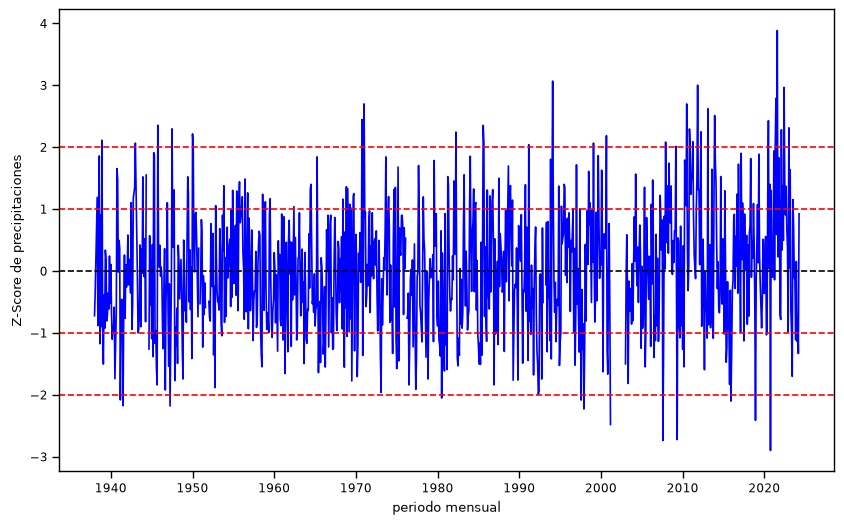

In [34]:
# graficando el historico del z-score
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ramada_data['FECHA'].dt.to_timestamp(), ramada_data['z_prec'], label='Z-Score', color='blue')
ax.axhline(0, color='black', linestyle='--', label='Media')
ax.axhline(1, color='red', linestyle='--', label='1 Desviación Estándar')
ax.axhline(-1, color='red', linestyle='--', label='-1 Desviación Estándar')
ax.axhline(2, color='red', linestyle='--', label='2 Desviaciones Estándar')
ax.axhline(-2, color='red', linestyle='--', label='-2 Desviaciones Estándar')
ax.set_xlabel('periodo mensual')
ax.set_ylabel('Z-Score de precipitaciones')

En el z-score ya no aparece una estacionalidad como la que observamos directamente en la curva de las precipitaciones. En este caso las desviaciones del cero corresponden a periodo en los que consistentemente las precipitaciones han sido mayores o menores a las precipitaciones históricas promedio.

___
#### Ejercicio 4
Repita el análisis realizado, pero esta vez use la estación 2120171  REPRESA SISGA. ¿Qué diferencias encuentra en la estacionalidad para esta estación?
___

In [48]:
# creando una nueva columna con el promedio de precipitaciones por mes
sisga_data['prom_prec'] = sisga_data.groupby('MES')['prec_trans'].transform('mean') # creando una nueva columna con el promedio de precipitaciones por mes
# creando una nueva columna con las desviación estándar de las precipitaciones por mes
sisga_data['std_prec'] = sisga_data.groupby('MES')['prec_trans'].transform('std') # creando una nueva columna con las desviación estándar de las precipitaciones por mes

sisga_data

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans,prom_prec,std_prec
0,1952,1,19.3,1952-01,REPRESA SISGA,2120171,5.05,73.44,4.393177,4.100003,2.334736
1,1952,2,18.0,1952-02,REPRESA SISGA,2120171,5.05,73.44,4.242641,4.695638,1.869761
2,1952,3,3.4,1952-03,REPRESA SISGA,2120171,5.05,73.44,1.843909,6.921666,2.551146
3,1952,4,17.5,1952-04,REPRESA SISGA,2120171,5.05,73.44,4.183300,9.285342,2.286702
4,1952,5,54.3,1952-05,REPRESA SISGA,2120171,5.05,73.44,7.368853,10.058923,1.902221
...,...,...,...,...,...,...,...,...,...,...,...
607,2019,8,NaN,2019-08,REPRESA SISGA,2120171,5.05,73.44,NaN,9.765314,1.713883
608,2019,9,NaN,2019-09,REPRESA SISGA,2120171,5.05,73.44,NaN,8.253119,1.621926
609,2019,10,NaN,2019-10,REPRESA SISGA,2120171,5.05,73.44,NaN,9.015178,2.135836
610,2019,11,NaN,2019-11,REPRESA SISGA,2120171,5.05,73.44,NaN,7.802970,1.861726


(np.float64(8401.0), np.float64(11688.0))

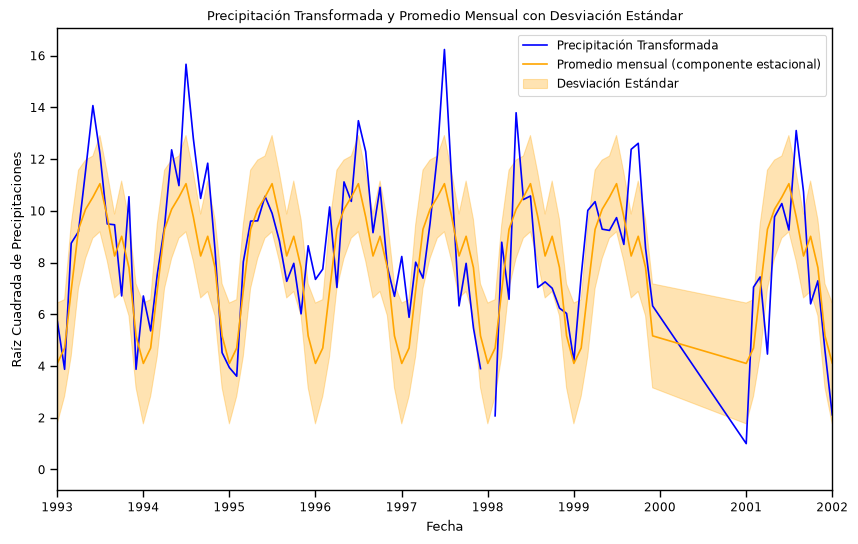

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

# Graficando la precipitación transformada
ax.plot(sisga_data['FECHA'].dt.to_timestamp(), sisga_data['prec_trans'], label='Precipitación Transformada', color='blue')

# Graficando el promedio mensual
ax.plot(sisga_data['FECHA'].dt.to_timestamp(), sisga_data['prom_prec'], label='Promedio mensual (componente estacional)', color='orange')

# Agregando una región de confianza para la desviación estándar
ax.fill_between(sisga_data['FECHA'].dt.to_timestamp(),
                sisga_data['prom_prec'] - sisga_data['std_prec'],
                sisga_data['prom_prec'] + sisga_data['std_prec'],
                color='orange', alpha=0.3, label='Desviación Estándar')

# Agregando etiquetas y título
ax.set_xlabel('Fecha')
ax.set_ylabel('Raíz Cuadrada de Precipitaciones')
ax.set_title('Precipitación Transformada y Promedio Mensual con Desviación Estándar')
ax.legend()
# Ajustando el rango del eje x
ax.set_xlim(pd.to_datetime('1993'),pd.to_datetime('2002'))

In [59]:
sisga_data['z_prec'] = (sisga_data['prec_trans']-sisga_data['prom_prec'])/sisga_data['std_prec'] # creando una nueva columna con el z-score de las precipitaciones transformadas
sisga_data

,AÑO,MES,PRECIPITACION,FECHA,NOMBRE,CODIGO,LONGITUD,LATITUD,prec_trans,prom_prec,std_prec,z_prec
0,1952,1,19.3,1952-01,REPRESA SISGA,2120171,5.05,73.44,4.393177,4.100003,2.334736,0.125570
1,1952,2,18.0,1952-02,REPRESA SISGA,2120171,5.05,73.44,4.242641,4.695638,1.869761,-0.242275
2,1952,3,3.4,1952-03,REPRESA SISGA,2120171,5.05,73.44,1.843909,6.921666,2.551146,-1.990383
3,1952,4,17.5,1952-04,REPRESA SISGA,2120171,5.05,73.44,4.183300,9.285342,2.286702,-2.231179
4,1952,5,54.3,1952-05,REPRESA SISGA,2120171,5.05,73.44,7.368853,10.058923,1.902221,-1.414173
...,...,...,...,...,...,...,...,...,...,...,...,...
607,2019,8,NaN,2019-08,REPRESA SISGA,2120171,5.05,73.44,NaN,9.765314,1.713883,NaN
608,2019,9,NaN,2019-09,REPRESA SISGA,2120171,5.05,73.44,NaN,8.253119,1.621926,NaN
609,2019,10,NaN,2019-10,REPRESA SISGA,2120171,5.05,73.44,NaN,9.015178,2.135836,NaN
610,2019,11,NaN,2019-11,REPRESA SISGA,2120171,5.05,73.44,NaN,7.802970,1.861726,NaN


Text(0, 0.5, 'Z-Score de precipitaciones')

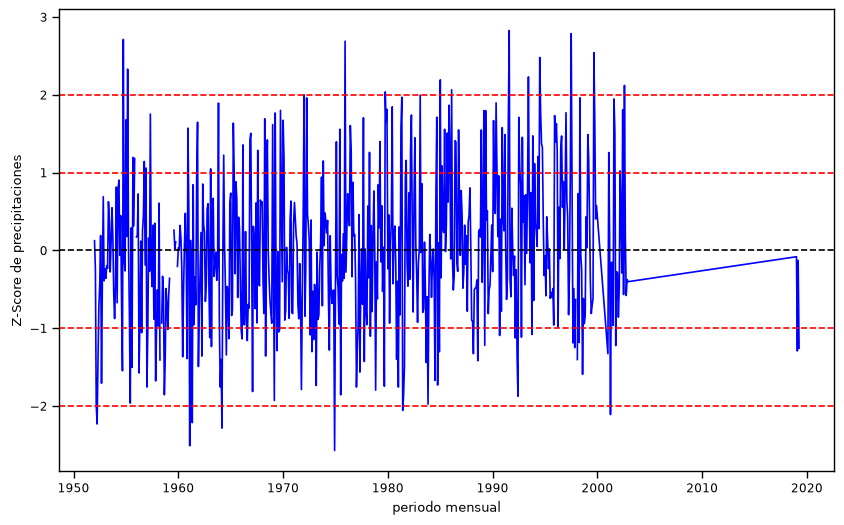

In [63]:
# graficando el historico del z-score
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sisga_data['FECHA'].dt.to_timestamp(), sisga_data['z_prec'], label='Z-Score', color='blue')
ax.axhline(0, color='black', linestyle='--', label='Media')
ax.axhline(1, color='red', linestyle='--', label='1 Desviación Estándar')
ax.axhline(-1, color='red', linestyle='--', label='-1 Desviación Estándar')
ax.axhline(2, color='red', linestyle='--', label='2 Desviaciones Estándar')
ax.axhline(-2, color='red', linestyle='--', label='-2 Desviaciones Estándar')
ax.set_xlabel('periodo mensual')
ax.set_ylabel('Z-Score de precipitaciones')

### Usando el promedio de variaciones de todas las estaciones en la base de datos

En este punto resulta razonable repetir el análisis anterior para todas las estaciones hidrológicas y posteriormente hacer un promedio de las variaciones sobre todas ellas para obtener las variaciones promedio en las precipitaciones en toda la región. Hablar del z-score en este caso es clave, ya que las estaciones están en zonas diferentes con niveles de precipitación diferentes, que no son comparables directamente.

Los pasos a seguir son los siguientes:

- Hacer una transformación general de los datos, usando la raíz cuadrada
- Agrupar los datos por estación y mes, y calcular el promedio y la desviación estándar. Estos valores deber ser agregados como columnas adicionales en la base de datos
- Calcular el z-score para toda la base de datos
- Finalmente, agrupar por periodo y promediar el z-score para obtener el promedio de las variaciones sobre todas las estaciones hidrológicas.

In [51]:
# crear las precipitaciones transformadas
prec_all['prec_trans'] = np.sqrt(prec_all['PRECIPITACION']) # transformando la variable de precipitaciones

# creando una nueva columna con el promedio de precipitaciones por mes
prec_all['prom_prec'] = prec_all.groupby(['CODIGO','MES'])['prec_trans'].transform('mean') # creando una nueva columna con el promedio de precipitaciones por mes

# creando una nueva columna con las desviación estándar de las precipitaciones por mes
prec_all['std_prec'] = prec_all.groupby(['CODIGO','MES'])['prec_trans'].transform('std') # creando una nueva columna con las desviación estándar de las precipitaciones por mes

# creando una nueva columna con el z-score de las precipitaciones transformadas
prec_all['z_prec'] = (prec_all['prec_trans']-prec_all['prom_prec'])/prec_all['std_prec'] # creando una nueva columna con el z-score de las precipitaciones transformadas

# promediando el z-score por periodo para obtener el promedio de variaciones
var_prom = prec_all.groupby(['FECHA'])['z_prec'].mean().reset_index() # promediando el z-score por periodo para obtener el promedio de variaciones

var_prom

,FECHA,z_prec
0,1919-01,2.517611
1,1919-02,0.353694
2,1919-03,1.251779
3,1919-04,1.656565
4,1919-05,0.678678
...,...,...
1147,2024-08,NaN
1148,2024-09,NaN
1149,2024-10,-0.357150
1150,2024-11,NaN


Veamos el resultado gráficamente

Text(0.5, 1.0, 'Promedio Regional de Variaciones de Precipitaciones Mensuales')

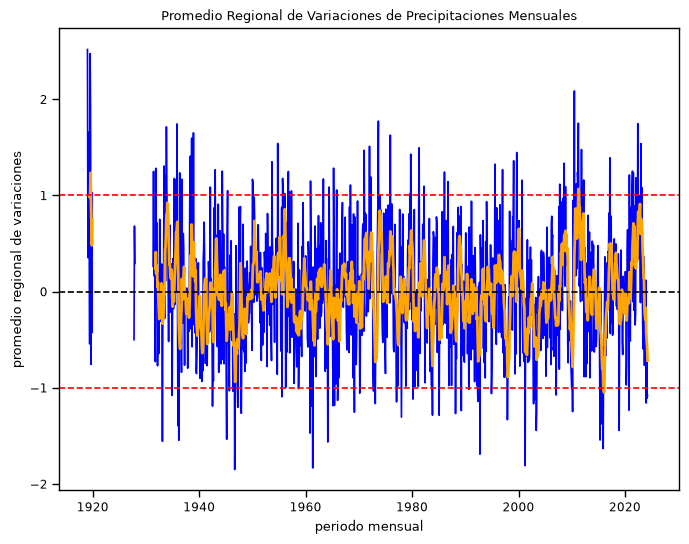

In [52]:
fig, ax = plt.subplots(figsize = (8,6))
# graficando el historico del z-score
ax.plot(var_prom['FECHA'].dt.to_timestamp(), var_prom['z_prec'], label='Z-Score', color='blue')
# graficando el promedio movil de 6 meses
ax.plot(var_prom['FECHA'].dt.to_timestamp(), var_prom['z_prec'].rolling(6).mean(), label='Promedio Móvil 6 meses', color='orange', linewidth=2)
# Añadiendo una región de confianza para la desviación estándar
ax.axhline(0, color='black', linestyle='--', label='Media')
ax.axhline(1, color='red', linestyle='--', label='1 Desviación Estándar')
ax.axhline(-1, color='red', linestyle='--', label='-1 Desviación Estándar')
# fijando los nombres de los ejes y el título
ax.set_xlabel('periodo mensual')
ax.set_ylabel('promedio regional de variaciones')
ax.set_title('Promedio Regional de Variaciones de Precipitaciones Mensuales')

Veamos el resultado de nuevo, pero esta vez en la ventana de los últimos 5 años

Text(0.5, 1.0, 'Promedio Regional de Variaciones de Precipitaciones Mensuales')

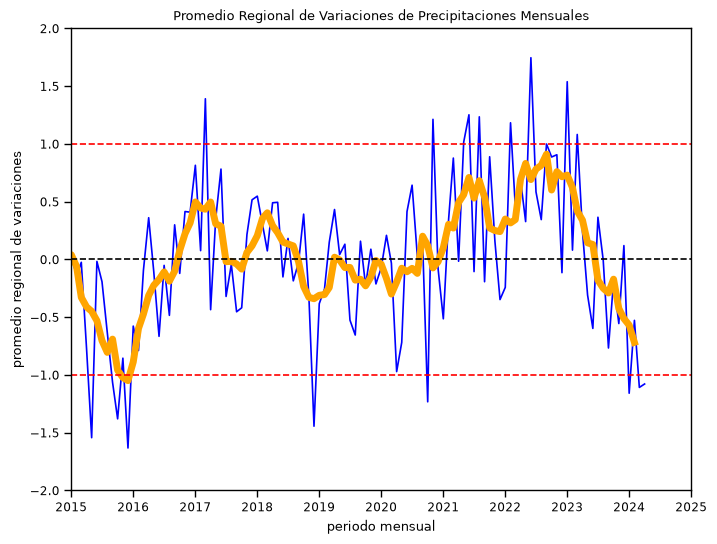

In [53]:
fig, ax = plt.subplots(figsize = (8,6))
# graficando el historico del z-score
ax.plot(var_prom['FECHA'].dt.to_timestamp(), var_prom['z_prec'], label='Z-Score', color='blue')
# graficando el promedio movil de 6 meses
ax.plot(var_prom['FECHA'].dt.to_timestamp(), var_prom['z_prec'].rolling(6, center=True).mean(), label='Promedio Móvil 6 meses', color='orange', linewidth=5)
ax.axhline(0, color='black', linestyle='--', label='Media')
ax.axhline(1, color='red', linestyle='--', label='1 Desviación Estándar')
ax.axhline(-1, color='red', linestyle='--', label='-1 Desviación Estándar')
ax.set_xlim(pd.to_datetime('2015'),pd.to_datetime('2025')) # ajustando el rango del eje x
ax.set_ylim(-2,2) # ajustando el rango del eje y

# fijando los nombres de los ejes y el título
ax.set_xlabel('periodo mensual')
ax.set_ylabel('promedio regional de variaciones')
ax.set_title('Promedio Regional de Variaciones de Precipitaciones Mensuales')

Veamos ahora cuál es la distribición de los valores del promedio móvil de precipitaciones, esto nos servirá para saber cuáles cuándo hay valores extremos.

Text(0, 0.5, 'conteo')

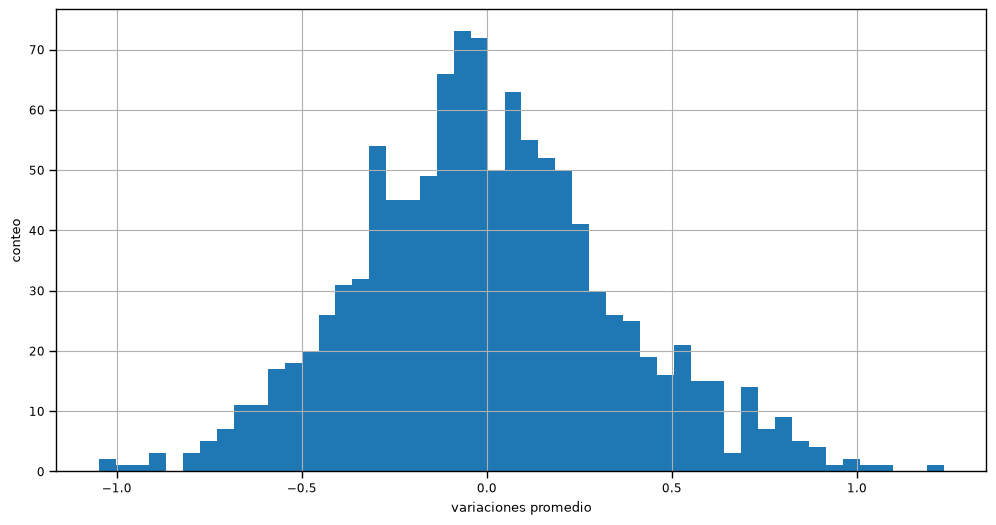

In [54]:
fig, ax = plt.subplots(figsize = (12,6))
var_prom['z_prec'].rolling(6, center=True).mean().hist(bins = 50)
ax.set_xlabel('variaciones promedio')
ax.set_ylabel('conteo')

Finalmente, podríamos decir que estamos ante un fenómeno de El Niño si los niveles del promedio móvil superan valores por encima de cierto límite. Y así generar una gráfica histórica de ocurrencias de un Fenómeno o el Otro

In [55]:
# definamos un límite para declarar épocas de sequía o de lluvias extremas
limite = 0.5

# Creamos una columna de ocurrencias, que inicialmente está en cero
var_prom['lluvias_extremas'] = 0
var_prom['sequia'] = 0

# si los niveles cambio están por encima del límite
mask = var_prom['z_prec'].rolling(6, center=True).mean() > limite
var_prom.loc[mask, 'lluvias_extremas'] = 1

# si los niveles de cambio están por debajo del límite
mask = var_prom['z_prec'].rolling(6, center=True).mean() < -limite
var_prom.loc[mask, 'sequia'] = -1

Ahora graficamos

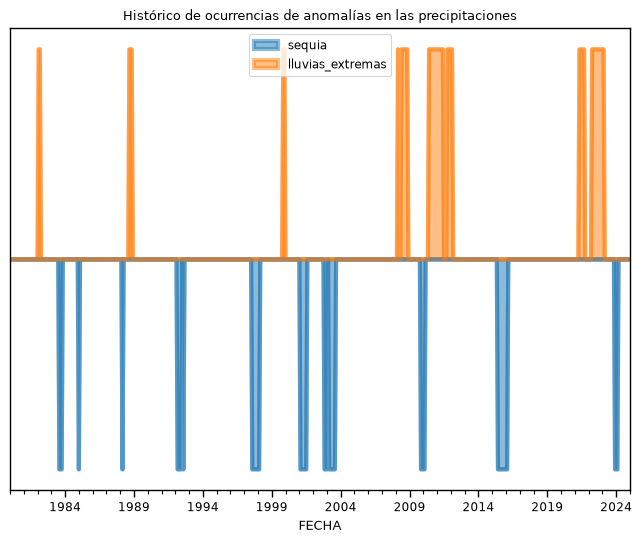

In [56]:
fig, ax = plt.subplots(figsize = (8,6), sharex=False)
var_prom.plot(kind = 'area', stacked = False, x='FECHA', y=['sequia', 'lluvias_extremas'], xlim = (datetime.date(1980,1,1), datetime.date(2025,1,1)), ax = ax, linewidth = 3)
ax.set_yticks([])
ax.set_title('Histórico de ocurrencias de anomalías en las precipitaciones')
ax.legend(loc = 'upper center')

## Conclusiones

* Hemos observado que, en general, Colombia tiene dos estaciones lluviosas y dos estaciones secas a lo largo del año. Sin, embargo, zonas específicas pueden mostrar perfiles anuales de lluvia con una sola estación seca y una sola estación lluviosa en el año.
* Logramos llevar a cabo un análisis de descomposición de series temporales para estaciones meteorológicas únicas y luego poder aplicar el mismo análisis a todas las estaciones de la base de datos
* Usando los valores promedio y la desviación estándar por mes, hemos logrado tener en cuenta la alta estacionalidad para definir la variación de las precipitaciones mes a mes.
* Promediando las variaciones mes a mes sobre todas las estaciones hidrológicas hemos logrado detectar periodos con niveles inusualmente bajos de lluvias y periodos con niveles inusualmente altos de lluvias en toda la región. 

### Origen de los datos

- Base de Datos de Precipitaciones Mensuales en las Estaciones Hidrológicas de la CAR - Corporación Autónoma Regional de Cundinamarca
